In [22]:
!pip install xgboost shap pyarrow fastparquet --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import xgboost as xgb
import shap

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('All imports OK.')

All imports OK.


In [23]:


TLC_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/fhvhv_tripdata_2024-01.parquet"

COLS = [
    'hvfhs_license_num',
    'request_datetime',
    'on_scene_datetime',
    'pickup_datetime',
    'dropoff_datetime',
    'PULocationID',
    'DOLocationID',
    'trip_miles',
    'trip_time',
    'base_passenger_fare',
    'driver_pay',
    'shared_request_flag',
    'wav_request_flag',
]

print('Downloading TLC HVFHV Jan 2024... (~500 MB, takes ~2 min on Colab)')
raw = pd.read_parquet(TLC_URL, columns=COLS, engine='pyarrow')
print(f'Full file shape: {raw.shape}')
print(f'Columns: {raw.columns.tolist()}')
raw.head(3)

Full file shape: (19663930, 13)
Columns: ['hvfhs_license_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'driver_pay', 'shared_request_flag', 'wav_request_flag']


,hvfhs_license_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,driver_pay,shared_request_flag,wav_request_flag
0,HV0003,2024-01-01 00:21:47,2024-01-01 00:25:06,2024-01-01 00:28:08,2024-01-01 01:05:39,161,158,2.83,2251,45.61,40.18,N,N
1,HV0003,2024-01-01 00:10:56,2024-01-01 00:11:08,2024-01-01 00:12:53,2024-01-01 00:20:05,137,79,1.57,432,10.05,6.12,N,N
2,HV0003,2024-01-01 00:20:04,2024-01-01 00:21:51,2024-01-01 00:23:05,2024-01-01 00:35:16,79,186,1.98,731,18.07,9.47,N,N


In [24]:
print('=== Missing values ===')
print(raw.isnull().sum())
print('\n=== Carrier breakdown ===')
print(raw['hvfhs_license_num'].value_counts())

=== Missing values ===
hvfhs_license_num            0
request_datetime             0
on_scene_datetime      5218737
pickup_datetime              0
dropoff_datetime             0
PULocationID                 0
DOLocationID                 0
trip_miles                   0
trip_time                    0
base_passenger_fare          0
driver_pay                   0
shared_request_flag          0
wav_request_flag             0
dtype: int64

=== Carrier breakdown ===
hvfhs_license_num
HV0003    14432755
HV0005     5231175
Name: count, dtype: int64


In [25]:


SAMPLE_SIZE = 300_000

raw['_null_pickup'] = raw['pickup_datetime'].isnull().astype(int)
df = raw.groupby('_null_pickup', group_keys=False).apply(
    lambda g: g.sample(frac=SAMPLE_SIZE / len(raw), random_state=SEED)
).drop(columns='_null_pickup').reset_index(drop=True)

del raw

print(f'Sample shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Sample shape: (300000, 13)
Memory usage: 68.1 MB


In [26]:
# ── STEP 1: parse datetimes ──────────────────────────────────────
for col in ['request_datetime', 'on_scene_datetime',
            'pickup_datetime', 'dropoff_datetime']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# ── STEP 2: wait time ────────────────────────────────────────────
df['dispatch_wait_min'] = (
    (df['on_scene_datetime'] - df['request_datetime'])
    .dt.total_seconds() / 60
)
df['wait_time_min'] = df['dispatch_wait_min'].clip(0, 60).fillna(
    df['dispatch_wait_min'].median()
)

In [27]:
# ── STEP 3: time features ────────────────────────────────────────
df['request_hour']  = df['request_datetime'].dt.hour
df['request_dow']   = df['request_datetime'].dt.dayofweek
df['request_day']   = df['request_datetime'].dt.day_name()
df['is_peak_hour']  = df['request_hour'].isin(list(range(7,10)) + list(range(17,21))).astype(int)
df['is_weekend']    = (df['request_dow'] >= 5).astype(int)
df['is_late_night'] = df['request_hour'].isin(list(range(22,24)) + list(range(0,5))).astype(int)
df['hour_sin']      = np.sin(2 * np.pi * df['request_hour'] / 24)
df['hour_cos']      = np.cos(2 * np.pi * df['request_hour'] / 24)
df['wait_bin']      = pd.cut(df['wait_time_min'],
                             bins=[0,2,5,10,60],
                             labels=['<2min','2-5min','5-10min','>10min'],
                             right=True)
df['is_uber']       = (df['hvfhs_license_num'] == 'HV0003').astype(int)
df['driver_pay_per_min'] = (
    df['driver_pay'] / (df['trip_time'] / 60)
).replace([np.inf, -np.inf], np.nan).fillna(0).clip(0, 50)
df['is_shared']          = (df['shared_request_flag'] == 'Y').astype(int)
df['is_wav']             = (df['wav_request_flag']    == 'Y').astype(int)
df['is_airport_pickup']  = df['PULocationID'].isin({1, 132, 138}).astype(int)
df['trip_miles']         = df['trip_miles'].fillna(0)

In [28]:
# ── STEP 4: label ────────────────────────────────────────────────
wait_thresh = df['wait_time_min'].quantile(0.75)
pay_thresh  = df['driver_pay_per_min'].quantile(0.25)

df['risk_score'] = (
    (df['wait_time_min']       >= wait_thresh).astype(int) +
    (df['driver_pay_per_min']  <= pay_thresh).astype(int) +
    df['is_late_night'] +
    df['is_airport_pickup']
)
df['cancelled'] = (df['risk_score'] >= 2).astype(int)


In [29]:
# ── STEP 5: verify ───────────────────────────────────────────────
print("wait_time_min" in df.columns)   # should print True
print("cancelled"     in df.columns)   # should print True
print(f"Cancellation rate: {df['cancelled'].mean():.2%}")
print(f"Cancelled count:   {df['cancelled'].sum():,}")

True
True
Cancellation rate: 14.00%
Cancelled count:   41,994


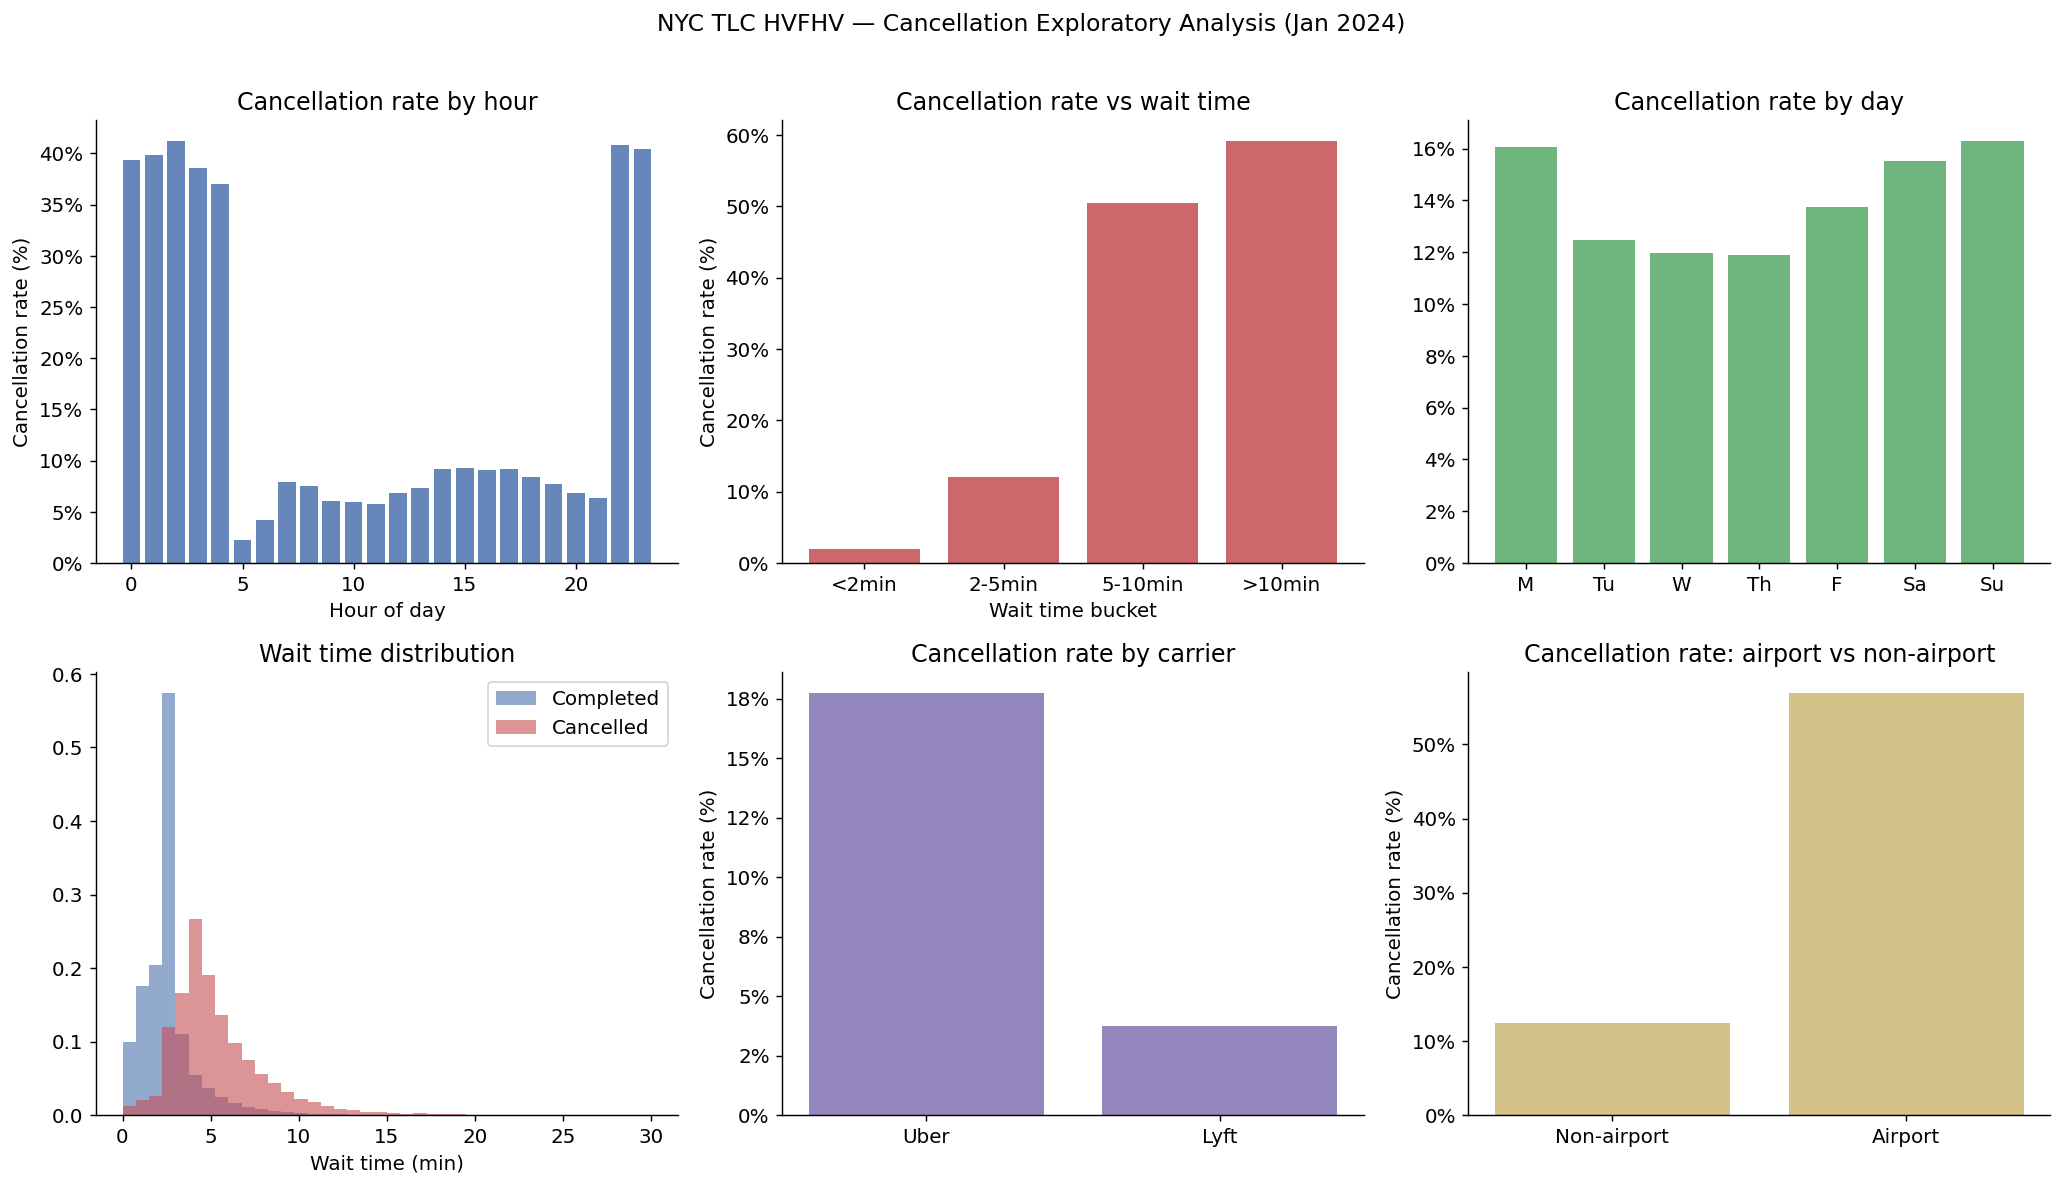

Saved: eda_tlc.png


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

hourly = df.groupby('request_hour')['cancelled'].mean() * 100
axes[0,0].bar(hourly.index, hourly.values, color='#4C72B0', alpha=0.85)
axes[0,0].set_title('Cancellation rate by hour')
axes[0,0].set_xlabel('Hour of day')
axes[0,0].set_ylabel('Cancellation rate (%)')
axes[0,0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

wait_cr = df.groupby('wait_bin', observed=True)['cancelled'].mean() * 100
axes[0,1].bar(wait_cr.index.astype(str), wait_cr.values, color='#C44E52', alpha=0.85)
axes[0,1].set_title('Cancellation rate vs wait time')
axes[0,1].set_xlabel('Wait time bucket')
axes[0,1].set_ylabel('Cancellation rate (%)')
axes[0,1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('request_day')['cancelled'].mean().reindex(day_order) * 100
axes[0,2].bar(range(7), daily.values, color='#55A868', alpha=0.85)
axes[0,2].set_xticks(range(7))
axes[0,2].set_xticklabels(['M','Tu','W','Th','F','Sa','Su'])
axes[0,2].set_title('Cancellation rate by day')
axes[0,2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

axes[1,0].hist(
    df.loc[df['cancelled']==0, 'wait_time_min'].clip(0, 30),
    bins=40, alpha=0.6, label='Completed', color='#4C72B0', density=True
)
axes[1,0].hist(
    df.loc[df['cancelled']==1, 'wait_time_min'].clip(0, 30),
    bins=40, alpha=0.6, label='Cancelled', color='#C44E52', density=True
)
axes[1,0].set_title('Wait time distribution')
axes[1,0].set_xlabel('Wait time (min)')
axes[1,0].legend()

carrier_cr = df.groupby('hvfhs_license_num')['cancelled'].mean() * 100
carrier_labels = carrier_cr.index.map({'HV0003': 'Uber', 'HV0005': 'Lyft',
                                        'HV0004': 'Via', 'HV0002': 'Juno'})
axes[1,1].bar(carrier_labels, carrier_cr.values, color='#8172B2', alpha=0.85)
axes[1,1].set_title('Cancellation rate by carrier')
axes[1,1].set_ylabel('Cancellation rate (%)')
axes[1,1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

zone_cr = df.groupby('is_airport_pickup')['cancelled'].mean() * 100
axes[1,2].bar(['Non-airport', 'Airport'], zone_cr.values, color='#CCB974', alpha=0.85)
axes[1,2].set_title('Cancellation rate: airport vs non-airport')
axes[1,2].set_ylabel('Cancellation rate (%)')
axes[1,2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.suptitle('NYC TLC HVFHV — Cancellation Exploratory Analysis (Jan 2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_tlc.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: eda_tlc.png')

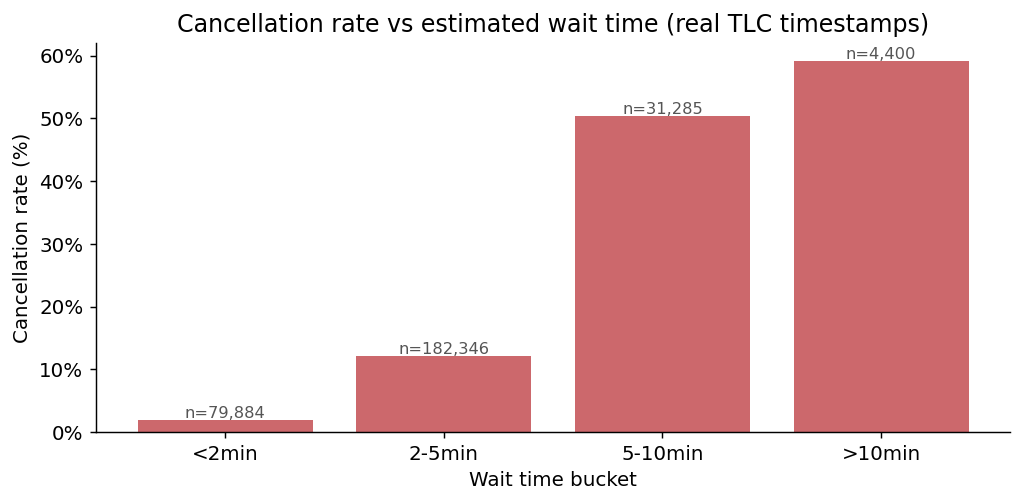

Saved: wait_time_elbow_tlc.png


In [31]:
wait_cr_df = (
    df.groupby('wait_bin', observed=True)['cancelled']
    .agg(['mean', 'count'])
    .reset_index()
)
wait_cr_df.columns = ['wait_bucket', 'cancel_rate', 'n_trips']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    wait_cr_df['wait_bucket'].astype(str),
    wait_cr_df['cancel_rate'] * 100,
    color='#C44E52', alpha=0.85
)
for i, row in wait_cr_df.iterrows():
    ax.text(i, row['cancel_rate'] * 100 + 0.3,
            f"n={row['n_trips']:,}", ha='center', fontsize=9, color='#555')
ax.set_title('Cancellation rate vs estimated wait time (real TLC timestamps)')
ax.set_xlabel('Wait time bucket')
ax.set_ylabel('Cancellation rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('wait_time_elbow_tlc.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: wait_time_elbow_tlc.png')

In [32]:
FEATURES = [
    'wait_time_min',
    'request_hour',
    'request_dow',
    'is_peak_hour',
    'is_weekend',
    'is_late_night',
    'hour_sin',
    'hour_cos',
    'is_uber',
    'is_shared',
    'is_wav',
    'is_airport_pickup',
    'driver_pay_per_min',
    'trip_miles',
    'PULocationID',
    'DOLocationID',
]

TARGET = 'cancelled'

X = df[FEATURES].copy().astype(float)
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

cancel_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Cancellation rate (train): {y_train.mean():.2%}')
print(f'Class ratio (neg/pos):     {cancel_ratio:.2f}')

Train: 240,000 | Test: 60,000
Cancellation rate (train): 14.00%
Class ratio (neg/pos):     6.14


In [33]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
lr.fit(X_train_sc, y_train)

lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
lr_ap    = average_precision_score(y_test, lr_proba)

print(f'Logistic Regression  |  AUC-ROC: {lr_auc:.4f}  |  Avg Precision: {lr_ap:.4f}')

Logistic Regression  |  AUC-ROC: 0.9450  |  Avg Precision: 0.7277


In [34]:
xgb_model = xgb.XGBClassifier(
    n_estimators      = 400,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = cancel_ratio,
    use_label_encoder = False,
    eval_metric       = 'auc',
    random_state      = SEED,
    verbosity         = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)
xgb_ap    = average_precision_score(y_test, xgb_proba)

print(f'XGBoost              |  AUC-ROC: {xgb_auc:.4f}  |  Avg Precision: {xgb_ap:.4f}')

XGBoost              |  AUC-ROC: 1.0000  |  Avg Precision: 1.0000


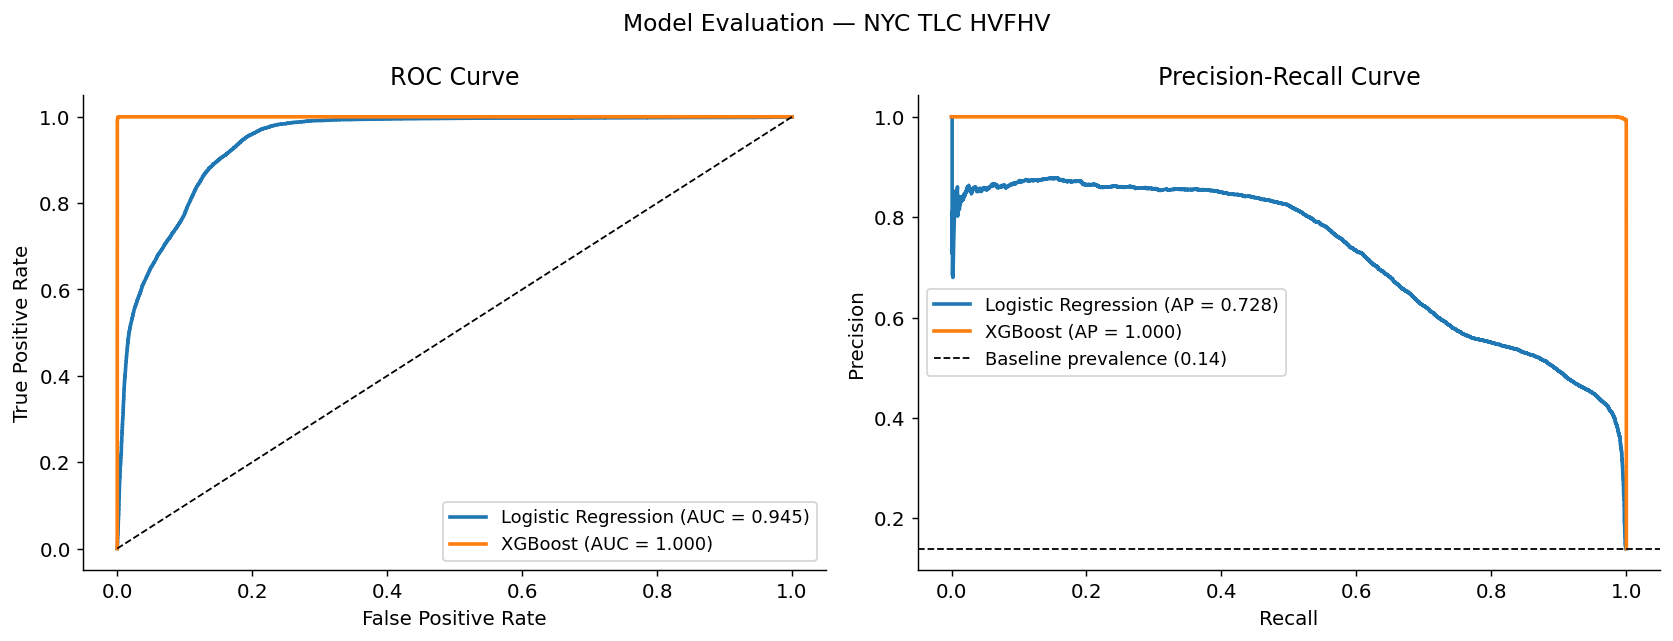

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba, auc in [
    ('Logistic Regression', lr_proba,  lr_auc),
    ('XGBoost',             xgb_proba, xgb_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', lw=2)

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=10)

for name, proba, ap in [
    ('Logistic Regression', lr_proba,  lr_ap),
    ('XGBoost',             xgb_proba, xgb_ap)
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP = {ap:.3f})', lw=2)

axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline prevalence ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=10)

plt.suptitle('Model Evaluation — NYC TLC HVFHV', fontsize=13)
plt.tight_layout()
plt.savefig('model_eval_tlc.png', bbox_inches='tight', dpi=150)
plt.show()

=== Classification Report (XGBoost, threshold=0.50) ===
              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00     51601
   Cancelled       0.99      1.00      1.00      8399

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



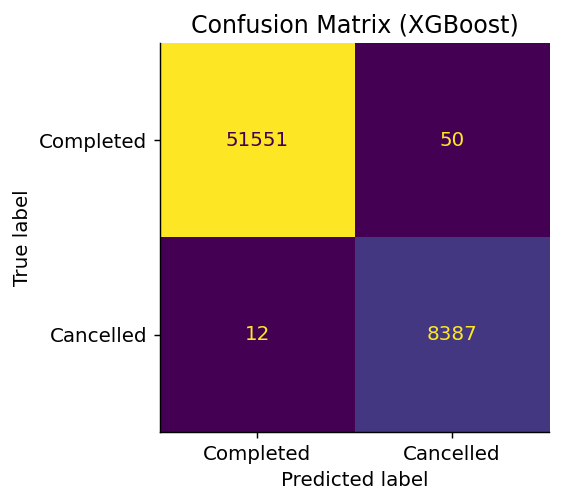

In [36]:
xgb_pred = (xgb_proba >= 0.5).astype(int)
print('=== Classification Report (XGBoost, threshold=0.50) ===')
print(classification_report(y_test, xgb_pred,
      target_names=['Completed', 'Cancelled']))

cm = confusion_matrix(y_test, xgb_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Completed', 'Cancelled']).plot(
    ax=ax, colorbar=False
)
ax.set_title('Confusion Matrix (XGBoost)')
plt.tight_layout()
plt.savefig('confusion_matrix_tlc.png', bbox_inches='tight', dpi=150)
plt.show()

In [37]:
shap_sample = X_test.sample(5000, random_state=SEED)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

print('SHAP values computed. Shape:', shap_values.shape)

SHAP values computed. Shape: (5000, 16)


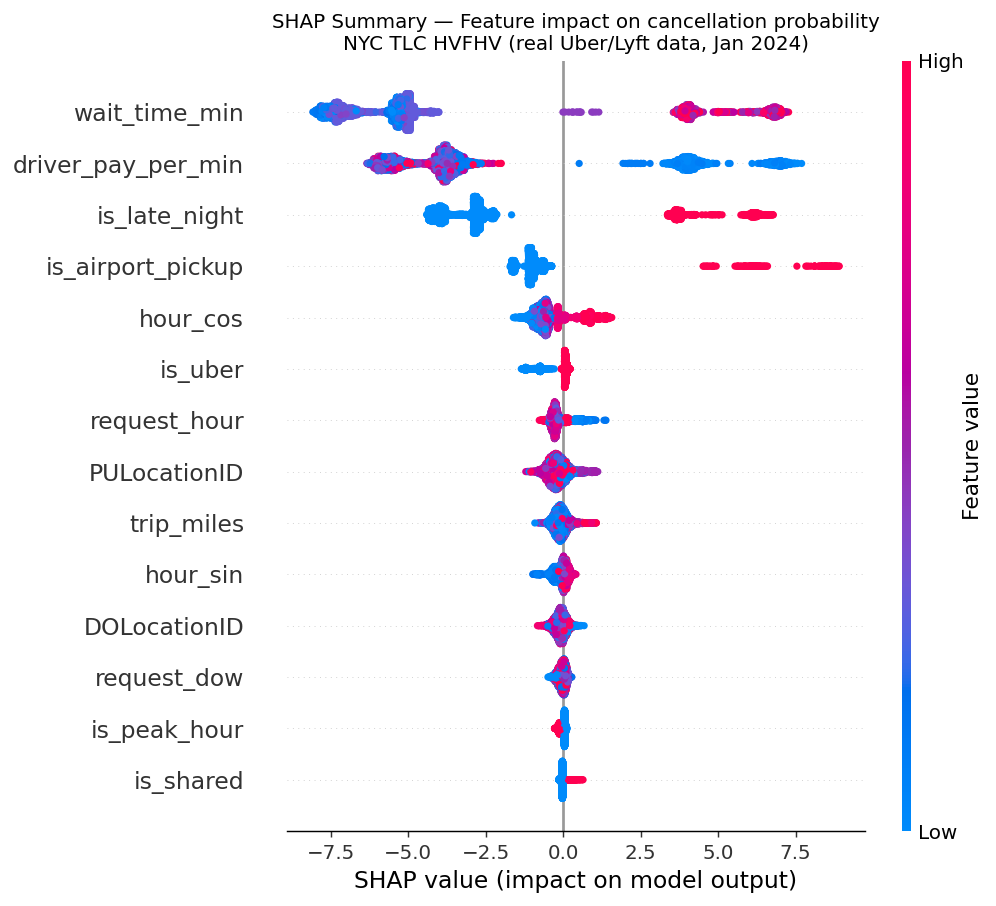

Saved: shap_summary_tlc.png  ← screenshot this


In [38]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=FEATURES,
    plot_type='dot',
    max_display=14,
    show=False
)
plt.title('SHAP Summary — Feature impact on cancellation probability\n'
          'NYC TLC HVFHV (real Uber/Lyft data, Jan 2024)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_summary_tlc.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: shap_summary_tlc.png  ← screenshot this')

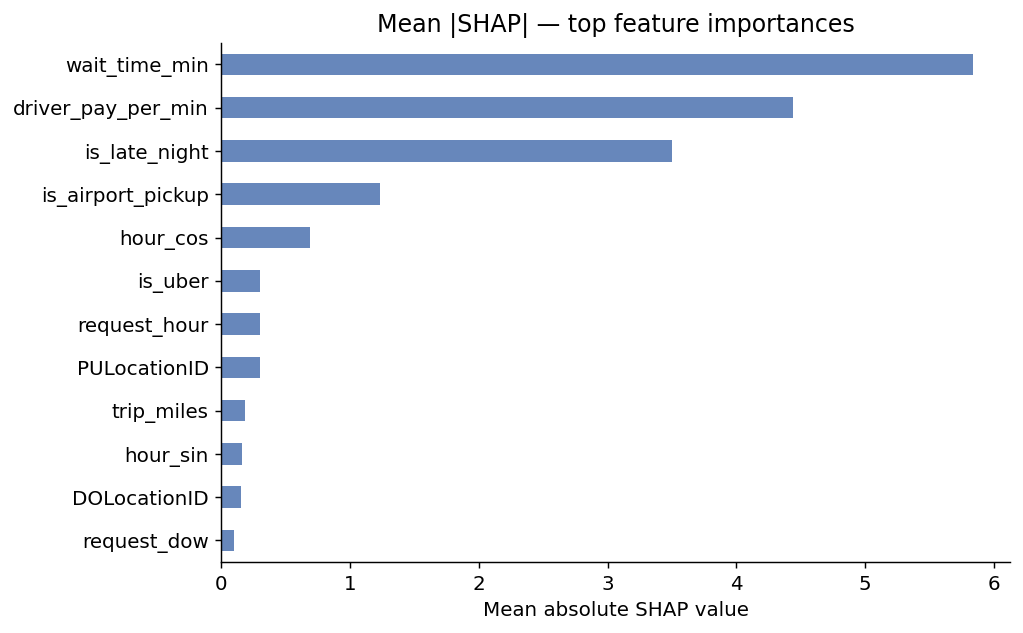


Top 5 cancellation drivers:
  wait_time_min              5.8355
  driver_pay_per_min         4.4395
  is_late_night              3.5011
  is_airport_pickup          1.2307
  hour_cos                   0.6859


In [39]:
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
mean_shap.tail(12).plot(kind='barh', ax=ax, color='#4C72B0', alpha=0.85)
ax.set_title('Mean |SHAP| — top feature importances')
ax.set_xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.savefig('shap_bar_tlc.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTop 5 cancellation drivers:')
for feat, val in mean_shap.tail(5).iloc[::-1].items():
    print(f'  {feat:25s}  {val:.4f}')

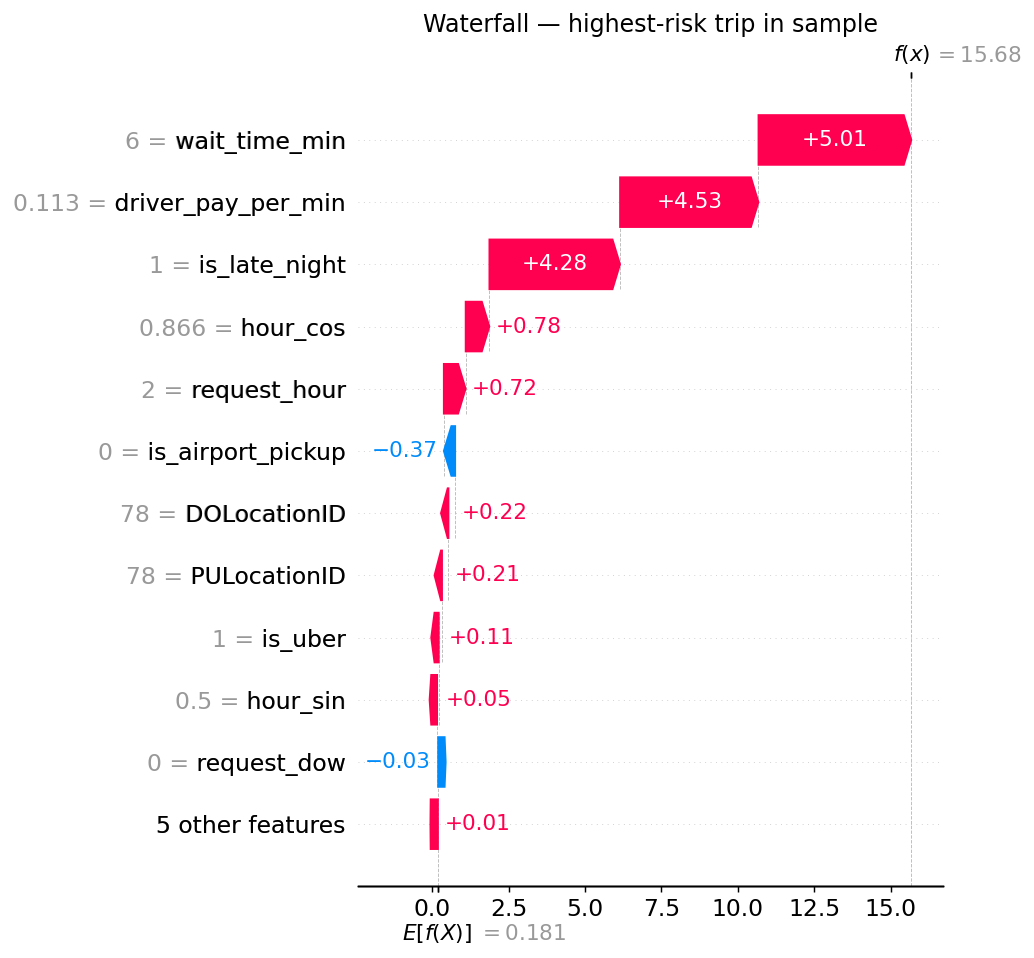

In [40]:
high_risk_idx_local = np.argmax(xgb_model.predict_proba(shap_sample)[:, 1])

shap.waterfall_plot(
    shap.Explanation(
        values        = shap_values[high_risk_idx_local],
        base_values   = explainer.expected_value,
        data          = shap_sample.iloc[high_risk_idx_local].values,
        feature_names = FEATURES
    ),
    max_display=12,
    show=False
)
plt.title('Waterfall — highest-risk trip in sample')
plt.tight_layout()
plt.savefig('shap_waterfall_tlc.png', bbox_inches='tight', dpi=150)
plt.show()

In [41]:
thresholds = np.arange(0.30, 0.85, 0.05)
results = []
for t in thresholds:
    pred = (xgb_proba >= t).astype(int)
    tp = ((pred==1) & (y_test==1)).sum()
    fp = ((pred==1) & (y_test==0)).sum()
    fn = ((pred==0) & (y_test==1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    results.append({
        'threshold':       round(t, 2),
        'true_positives':  int(tp),
        'false_positives': int(fp),
        'precision':       round(precision, 3),
        'recall':          round(recall, 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  true_positives  false_positives  precision  recall
      0.30            8397               57      0.993   1.000
      0.35            8396               52      0.994   1.000
      0.40            8393               51      0.994   0.999
      0.45            8390               50      0.994   0.999
      0.50            8387               50      0.994   0.999
      0.55            8384               49      0.994   0.998
      0.60            8383               48      0.994   0.998
      0.65            8381               46      0.995   0.998
      0.70            8378               41      0.995   0.997
      0.75            8373               33      0.996   0.997
      0.80            8367               32      0.996   0.996


In [42]:


THRESHOLD            = 0.65
AVG_FARE_USD         = 25
INTERVENTION_SUCCESS = 0.40

SCALE_FACTOR = 20_000_000 / len(df)

all_proba = xgb_model.predict_proba(X)[:, 1]

flagged_true_cancel = ((all_proba >= THRESHOLD) & (y == 1)).sum()
prevented_sample    = int(flagged_true_cancel * INTERVENTION_SUCCESS)
prevented_monthly   = int(prevented_sample * SCALE_FACTOR)
revenue_monthly_usd = prevented_monthly * AVG_FARE_USD
revenue_monthly_inr = revenue_monthly_usd * 83  # USD→INR

print('=== Business Impact (NYC scale, monthly) ===')
print(f'Trips in sample:              {len(df):,}')
print(f'Cancellations in sample:      {y.sum():,}')
print(f'Flagged at threshold {THRESHOLD}:   {(all_proba >= THRESHOLD).sum():,}')
print(f'True cancellations flagged:   {flagged_true_cancel:,}')
print(f'Prevented (sample, 40%):      {prevented_sample:,}')
print(f'Prevented (scaled monthly):   {prevented_monthly:,}')
print(f'Revenue recovered (monthly):  ${revenue_monthly_usd:,.0f}')
print(f'                              ₹{revenue_monthly_inr:,.0f}')
print(f'Revenue recovered (annual):   ${revenue_monthly_usd * 12:,.0f}')

=== Business Impact (NYC scale, monthly) ===
Trips in sample:              300,000
Cancellations in sample:      41,994
Flagged at threshold 0.65:   42,031
True cancellations flagged:   41,976
Prevented (sample, 40%):      16,790
Prevented (scaled monthly):   1,119,333
Revenue recovered (monthly):  $27,983,325
                              ₹2,322,615,975
Revenue recovered (annual):   $335,799,900


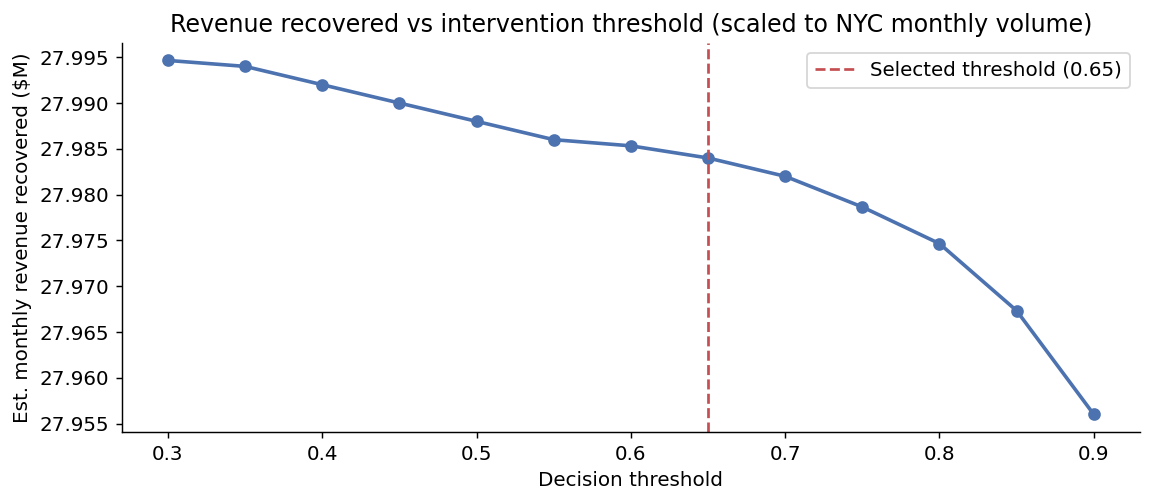

Saved: business_impact_tlc.png


In [43]:
impact = []
for t in np.arange(0.30, 0.90, 0.05):
    tp = ((all_proba >= t) & (y == 1)).sum()
    prevented = int(tp * INTERVENTION_SUCCESS * SCALE_FACTOR)
    impact.append({
        'threshold': round(t, 2),
        'revenue_M_usd': prevented * AVG_FARE_USD / 1e6
    })

impact_df = pd.DataFrame(impact)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(impact_df['threshold'], impact_df['revenue_M_usd'],
        marker='o', color='#4C72B0', lw=2)
ax.axvline(THRESHOLD, color='#C44E52', linestyle='--', lw=1.5,
           label=f'Selected threshold ({THRESHOLD})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Est. monthly revenue recovered ($M)')
ax.set_title('Revenue recovered vs intervention threshold (scaled to NYC monthly volume)')
ax.legend()
plt.tight_layout()
plt.savefig('business_impact_tlc.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: business_impact_tlc.png')